Extraction complete.
Dataset loaded successfully!
Preprocessing data...
Training Decision Tree model...

--- Model Evaluation ---
Accuracy: 0.8972

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       807
           1       0.54      0.35      0.42        98

    accuracy                           0.90       905
   macro avg       0.73      0.66      0.68       905
weighted avg       0.88      0.90      0.89       905



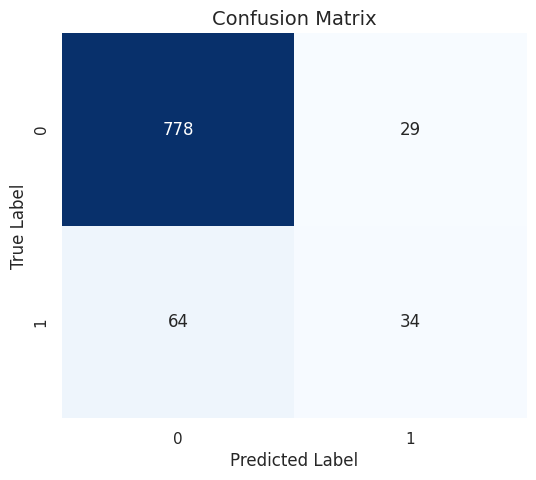

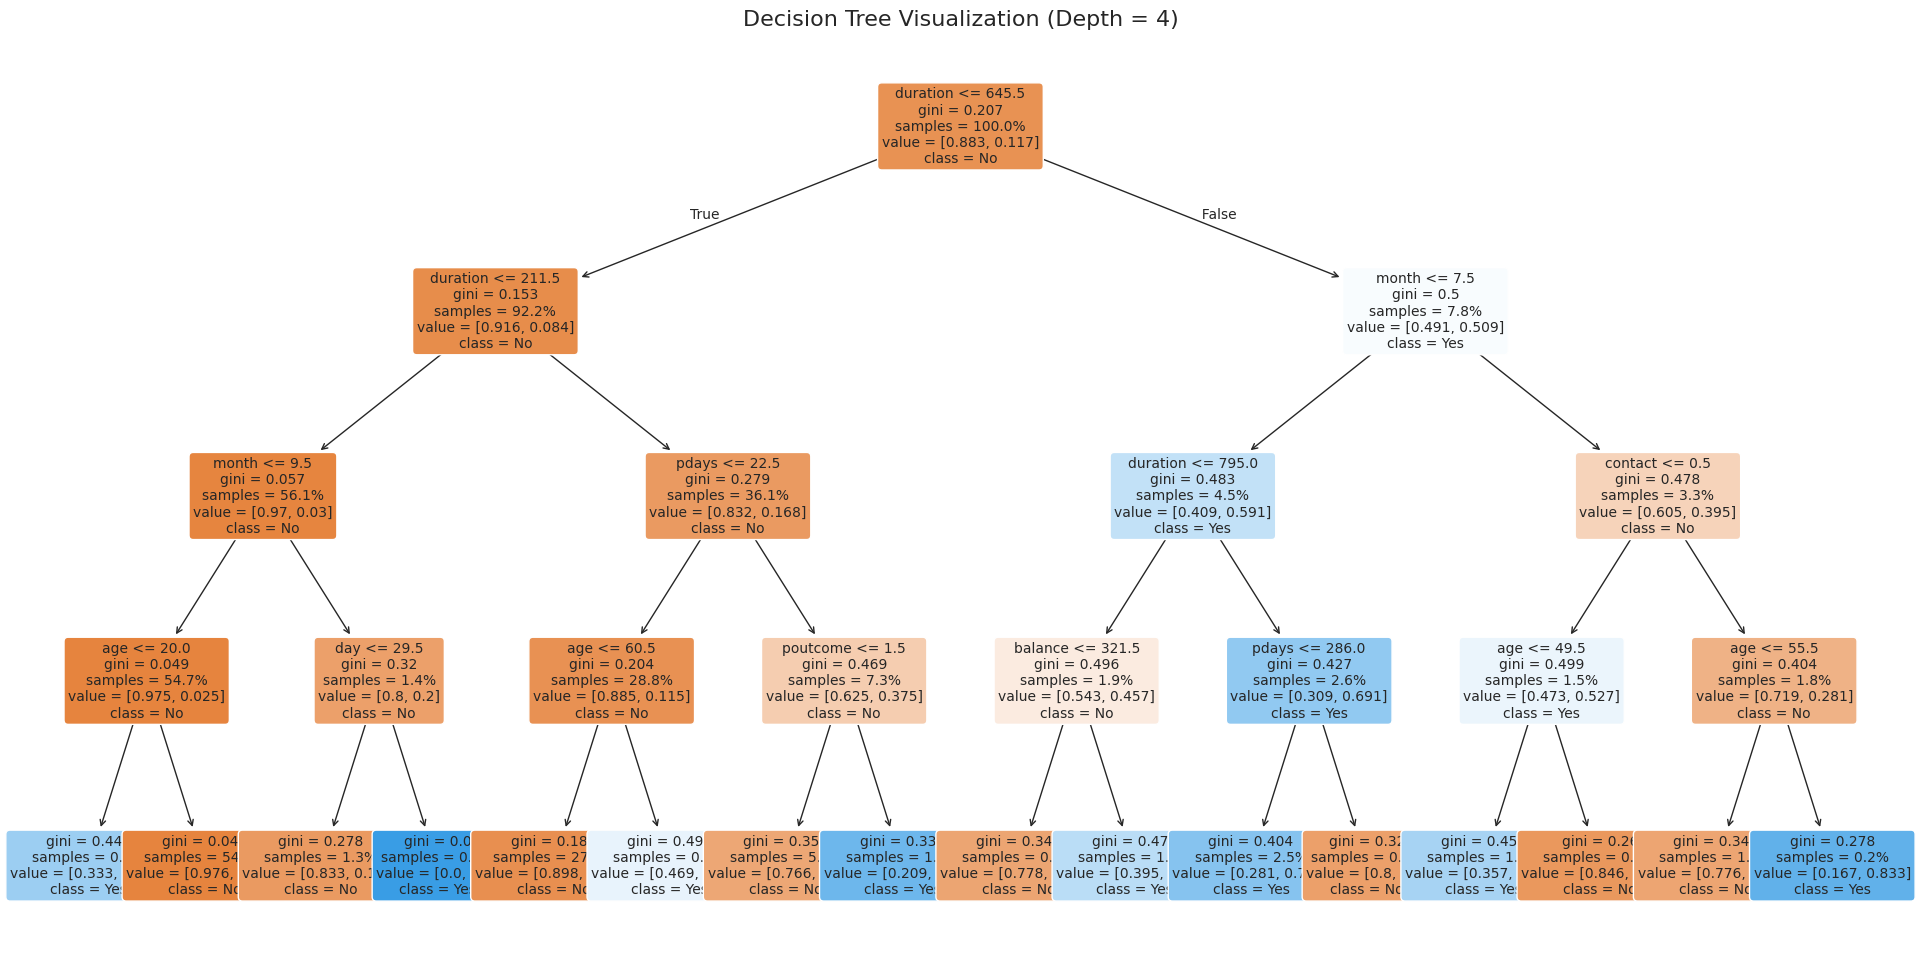

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# TASK 3: Decision Tree Classifier
# Dataset: Bank Marketing Dataset (UCI)

import urllib.request
import zipfile
import os

def load_data():
    """Downloads, extracts, and loads the Bank Marketing dataset directly from UCI."""
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'
    zip_path = 'bank.zip'
    csv_path = 'bank.csv'

    try:
        # Download the zip file if it doesn't exist yet
        if not os.path.exists(csv_path):
            print("Downloading dataset from UCI repository...")
            urllib.request.urlretrieve(url, zip_path)

            # Extract the zip file
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall()
            print("Extraction complete.")

        # The UCI Bank Marketing dataset uses ';' as a separator
        df = pd.read_csv(csv_path, sep=';')
        print("Dataset loaded successfully!")
        return df

    except Exception as e:
        print(f"Error loading data: {e}")
        return None



def preprocess_data(df):
    """Encodes categorical variables for the Decision Tree model."""
    print("Preprocessing data...")
    df_processed = df.copy()

    label_encoders = {}

    for column in df_processed.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df_processed[column] = le.fit_transform(df_processed[column])
        label_encoders[column] = le

    return df_processed

def train_and_evaluate(df):
    """Trains the decision tree, evaluates performance, and visualizes results."""
    print("Training Decision Tree model...")

    X = df.drop('y', axis=1)
    y = df['y']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    clf = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    sns.set_theme(style="white")

    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    plt.figure(figsize=(24, 12))
    plot_tree(clf,
              feature_names=X.columns,
              class_names=['No', 'Yes'],
              filled=True,
              rounded=True,
              fontsize=10,
              proportion=True)
    plt.title('Decision Tree Visualization (Depth = 4)', fontsize=16)
    plt.show()

def main():
    # Execute Pipeline
    df = load_data()  # URL is now handled inside the function

    if df is not None:
        processed_df = preprocess_data(df)
        train_and_evaluate(processed_df)

if __name__ == "__main__":
    main()